In [54]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

rng = np.random.default_rng(30)

Part 1

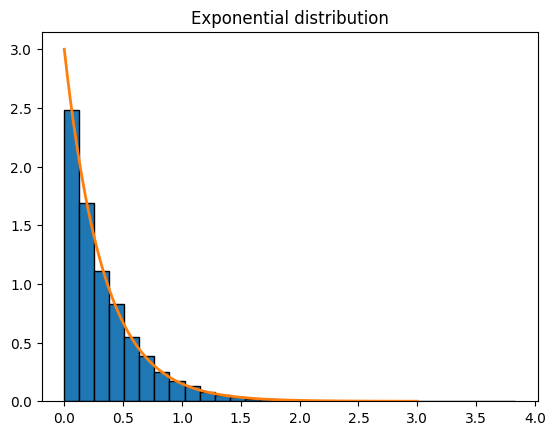

KS statistic D = 0.009073808507055636
Adjusted KS statistic D^* = 0.908479688915768


In [55]:
rng = np.random.default_rng(20)

def exponential(lbd, rng):
    U = rng.uniform(0,1)
    X = -np.log(U)/lbd
    return X

def exponential_analytical(x, lbd):
    return lbd * np.exp(-lbd * x)

lbd = 3
obs_exponential = [exponential(lbd, rng) for _ in range(10000)]
t = np.linspace(0, 3, 10000)
plt.hist(obs_exponential, bins=30, density=True, edgecolor='black')
plt.plot(t, exponential_analytical(t, lbd), linewidth=2)
plt.title('Exponential distribution')
plt.show()


## Kolmogorov-Smirnov test

def smirnov(data, CDF):
    data_sorted = np.sort(data)
    p = np.arange(len(data_sorted)) / (len(data_sorted) - 1)   # empirical CDF
    p_cdf = CDF(data_sorted)                      # theoretical CDF
    D = np.max(np.abs(p - p_cdf))                 # sup
    return D

# Theoretical exponential CDF
def exp_cdf(x):
    return 1 - np.exp(-lbd * x)

D = smirnov(obs_exponential, exp_cdf)
print("KS statistic D =", D)

n = 10000
D_adjusted = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * D
print("Adjusted KS statistic D^* =", D_adjusted)

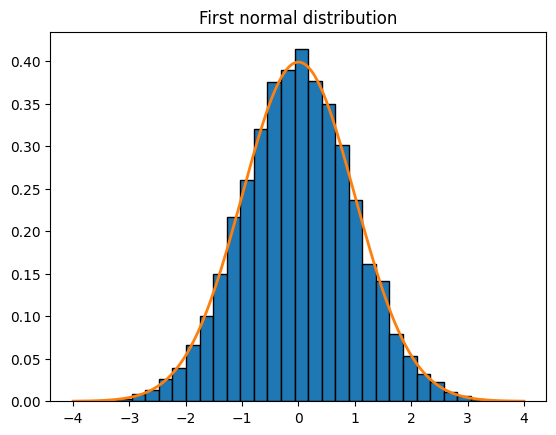

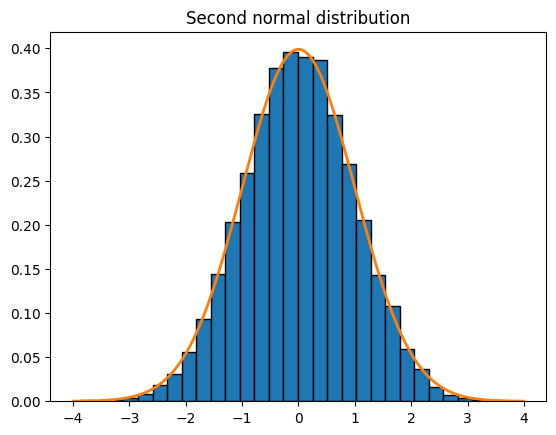

D1 = 0.008404349905213992
D2 = 0.006430555350442152
Adjusted KS statistic D1^* = 0.8414527572949206
Adjusted KS statistic D2^* = 0.6438342752971538


In [56]:
rng = np.random.default_rng(30)

def normal(rng):
    U1 = rng.uniform(0,1)
    U2 = rng.uniform(0,1)
    Z1 = np.sqrt(-2*np.log(U1)) * np.cos(2*np.pi*U2)
    Z2 = np.sqrt(-2*np.log(U1)) * np.sin(2*np.pi*U2)
    return np.array([Z1, Z2])

def normal_analytical(x):
    return (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x**2)

obs_normal = np.array([normal(rng) for _ in range(10000)])
t = np.linspace(-4, 4, 500)

plt.hist(obs_normal[:,0], bins=30, density=True, edgecolor='black')
plt.plot(t, normal_analytical(t), linewidth=2)
plt.title('First normal distribution')
plt.show()

plt.hist(obs_normal[:,1], bins=30, density=True, edgecolor='black')
plt.plot(t, normal_analytical(t), linewidth=2)
plt.title('Second normal distribution')
plt.show()

## Kolmogorov-Smirnov test

D1 = smirnov(obs_normal[:,0], ss.norm.cdf)
D2 = smirnov(obs_normal[:,1], ss.norm.cdf)

print("D1 =", D1)
print("D2 =", D2)

n = 10000
D1_adjusted = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * D1
print("Adjusted KS statistic D1^* =", D1_adjusted)
D2_adjusted = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * D2
print("Adjusted KS statistic D2^* =", D2_adjusted)

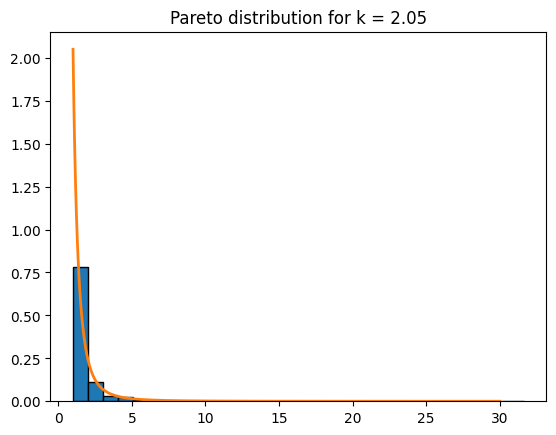

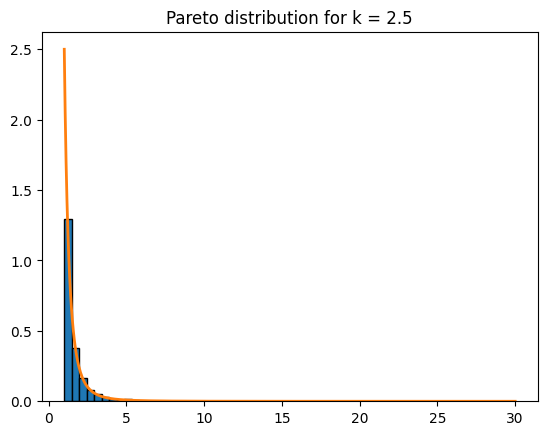

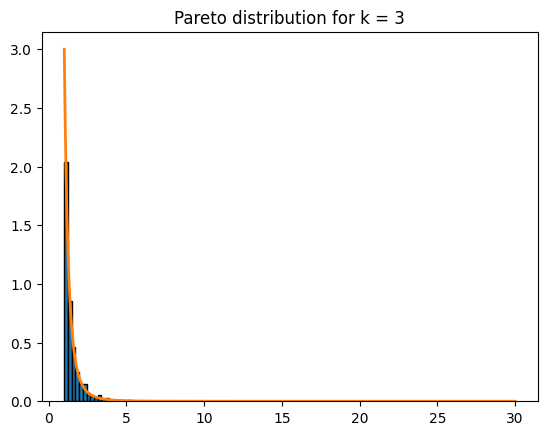

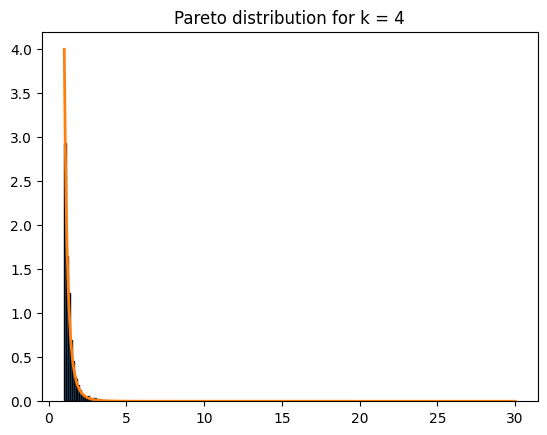

k = 2.05, KS statistic D = 0.02397
Adjusted KS statistic D^* = 0.7609072793486111
k = 2.5, KS statistic D = 0.03580
Adjusted KS statistic D^* = 1.1366408375755497
k = 3, KS statistic D = 0.02883
Adjusted KS statistic D^* = 0.9153369286476333
k = 4, KS statistic D = 0.03294
Adjusted KS statistic D^* = 1.0456042810858237


In [57]:
rng = np.random.default_rng(30)

def pareto(k, beta, rng):
    U = rng.uniform(0,1)
    X = beta * U**(-1/k)
    return X

def pareto_analytical(t, k, beta):
    return (k * beta**k) / (t**(k+1))

beta = 1
k = [2.05, 2.5, 3, 4]
t = np.linspace(1, 30, 500)
for ki in k:
    obs_pareto = np.array([pareto(ki, beta, rng) for _ in range(1000)])
    plt.hist(obs_pareto, density=True, bins=30, edgecolor='black')
    plt.plot(t, pareto_analytical(t, ki, beta), linewidth=2)
    plt.title(f"Pareto distribution for k = {ki}")
    plt.show()


## Kolmogorov-Smirnov test

def pareto_cdf(x, k, beta):
    x = np.asarray(x)
    return 1 - (beta / x)**k

for ki in k:
    obs_pareto = np.array([pareto(ki, beta, rng) for _ in range(1000)])
    D = smirnov(obs_pareto, lambda x: pareto_cdf(x, ki, beta))
    print(f"k = {ki}, KS statistic D = {D:.5f}")

    n = 1000
    D_adjusted = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * D
    print("Adjusted KS statistic D^* =", D_adjusted)


Part 2

In [60]:
rng = np.random.default_rng(30)

for ki in k:
    obs_pareto = np.array([pareto(ki, beta, rng) for _ in range(1000)])
    mean_obs = np.mean(obs_pareto)
    var_obs = np.var(obs_pareto)
    # print(var_obs)
    mean_analytical = beta * ki / (ki - 1)
    var_analytical = beta**2 * ki / ((ki-1)**2 * (ki-2))
    print('Simulated mean = ', mean_obs, 'VS theoritical mean =', mean_analytical)
    #print('For k=', ki, 'the difference between the means is', mean_obs - mean_analytical)
    print('Simulated variance = ', var_obs, 'VS theoritical variance =', var_analytical)
    #print('For k=', ki, 'the difference between the variances is', var_obs - var_analytical)


Simulated mean =  1.8104400037759363 VS theoritical mean = 1.9523809523809526
Simulated variance =  2.5585255104885927 VS theoritical variance = 37.18820861678019
Simulated mean =  1.660496941649581 VS theoritical mean = 1.6666666666666667
Simulated variance =  1.235568577494041 VS theoritical variance = 2.2222222222222223
Simulated mean =  1.4858218110975532 VS theoritical mean = 1.5
Simulated variance =  0.4571060128263759 VS theoritical variance = 0.75
Simulated mean =  1.3371868988353561 VS theoritical mean = 1.3333333333333333
Simulated variance =  0.17111632969993978 VS theoritical variance = 0.2222222222222222


Part 3

In [59]:
rng = np.random.default_rng(30)

obs_normal = np.array([normal() for _ in range(10000)]).flatten()

n = 10
B = 100

mean_conf_inter = []
var_conf_inter = []
conf_lvl = 0.95

for _ in range(B):
    sample = rng.choice(obs_normal, size=n, replace=False)

    mean_normal = np.mean(sample)
    var_normal = np.var(sample)
    var2_normal = np.sqrt(var_normal)

    t_crit = ss.t.ppf(0.975, df=n-1)
    mean_ci = (mean_normal - t_crit * var2_normal / np.sqrt(n), mean_normal + t_crit * var2_normal / np.sqrt(n))

    chi2_low = ss.chi2.ppf(0.025, df=n-1)
    chi2_high = ss.chi2.ppf(0.975, df=n-1)

    var_ci = ((n-1)*var_normal / chi2_high, (n-1)*var_normal / chi2_low)

    mean_conf_inter.append(mean_ci)
    var_conf_inter.append(var_ci)

mean_intervals = np.array(mean_conf_inter)
var_intervals = np.array(var_conf_inter)

print("First 5 mean CIs:\n", mean_conf_inter[:5])
print("First 5 variance CIs:\n", var_conf_inter[:5])

TypeError: normal() missing 1 required positional argument: 'rng'

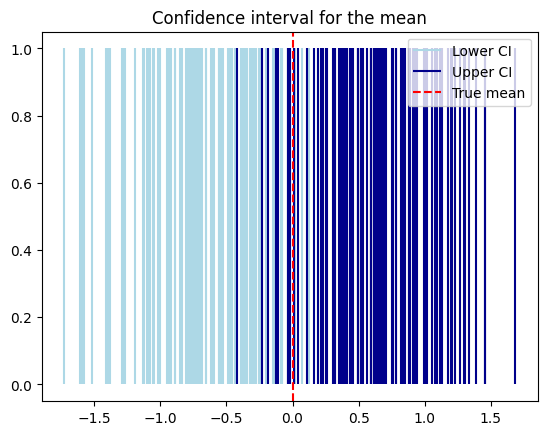

In [ ]:
# MEAN CONFIDENCE INTERVAL
plt.vlines(mean_intervals[:,0],0,1,color="lightblue", label="Lower CI")
plt.vlines(mean_intervals[:,1],0,1,color="darkblue", label="Upper CI")

plt.axvline(0, color='red', linestyle='--', label="True mean")  # true mean
plt.title("Confidence interval for the mean")
plt.legend()
plt.show()

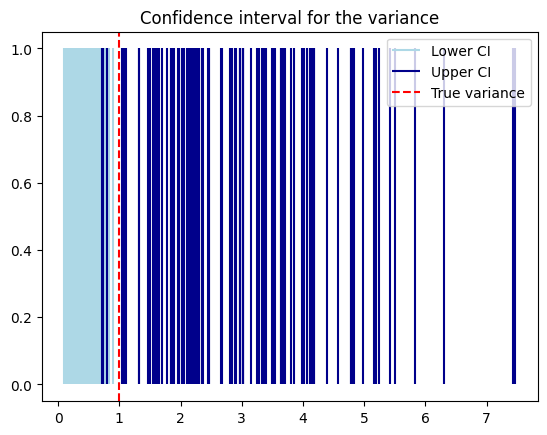

In [ ]:
# VARIANCE CONFIDENCE INTERVAL
plt.vlines(var_intervals[:,0],0,1,color="lightblue", label="Lower CI")
plt.vlines(var_intervals[:,1],0,1,color="darkblue", label="Upper CI")

plt.axvline(1, color='red', linestyle='--', label="True variance")  # true mean
plt.title("Confidence interval for the variance")
plt.legend()
plt.show()

In [ ]:
# Coverage MEAN
num = (mean_intervals[:,0] <= 0) & (mean_intervals[:,1] >= 0)
print(f"Coverage mean: {np.sum(num)/100}")

# Coverage variance
num = (var_intervals[:,0] <= 1) & (var_intervals[:,1] >= 1)
print(f"Coverage variance: {np.sum(num)/100}")

Coverage mean: 0.87
Coverage variance: 0.95


Part 4

In [ ]:
N = 10_000
beta = 1
mu = beta
lbd = 0.2
U1 = np.random.uniform(low=0, high=1, size=N)
U2 = np.random.uniform(low=0, high=1, size=N)
Y = - np.log(U1)/lbd
X_pareto_comp = - np.log(U2)/Y

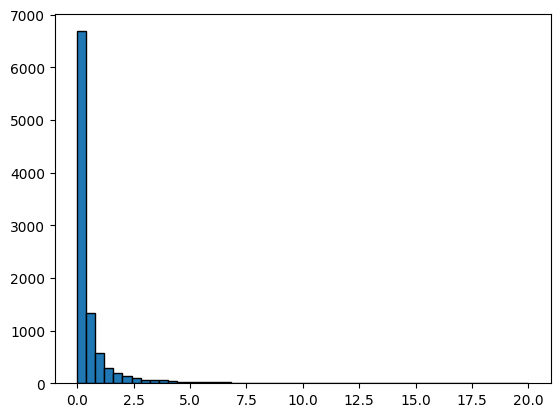

In [ ]:

plt.hist(X_pareto_comp, bins=50, range=(0,20), edgecolor='black')
plt.show()